In [1]:
import matplotlib.pyplot as plt 
from sklearn.datasets import make_blobs 
import pandas as pd 
import numpy as np 
%matplotlib inline

In [2]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [3]:
X

array([[-2.01860951, -1.56770287],
       [-1.00470717,  9.52831194],
       [-2.15821154,  8.98047823],
       ...,
       [-1.23058066, -0.40859843],
       [-1.25265273,  9.90389019],
       [-2.64049221, 10.0334655 ]], shape=(1000, 2))

In [4]:
y

array([0, 2, 2, 1, 0, 2, 0, 1, 1, 0, 0, 0, 2, 2, 2, 0, 2, 0, 1, 2, 1, 1,
       1, 2, 2, 2, 2, 0, 1, 2, 2, 2, 2, 1, 0, 1, 0, 1, 1, 2, 1, 0, 0, 2,
       2, 0, 2, 0, 0, 0, 2, 1, 2, 2, 1, 0, 1, 0, 0, 1, 1, 0, 0, 2, 1, 2,
       1, 2, 1, 0, 0, 2, 1, 0, 2, 1, 2, 1, 2, 2, 1, 0, 1, 1, 0, 2, 0, 1,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 0, 1, 2, 2,
       2, 0, 0, 0, 2, 1, 2, 1, 1, 2, 1, 2, 2, 1, 0, 2, 1, 2, 0, 0, 2, 2,
       0, 1, 1, 1, 2, 0, 0, 1, 0, 2, 2, 0, 1, 0, 1, 0, 2, 1, 2, 0, 2, 0,
       1, 0, 1, 2, 1, 2, 0, 0, 0, 2, 0, 2, 1, 0, 1, 0, 0, 0, 0, 2, 1, 1,
       1, 1, 1, 1, 0, 2, 1, 1, 0, 0, 2, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 2,
       2, 2, 1, 2, 2, 2, 1, 2, 1, 0, 0, 1, 1, 2, 0, 2, 0, 2, 0, 0, 0, 0,
       2, 1, 1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 2, 2, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 2, 0, 1, 1, 1, 0, 0, 2, 1, 1, 1, 0, 2, 0, 2, 1, 1, 2, 0,
       0, 2, 1, 1, 2, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 2, 2, 1, 1, 0, 2, 1,
       1, 0, 1, 2, 2, 1, 1, 2, 2, 1, 2, 0, 0, 0, 0,

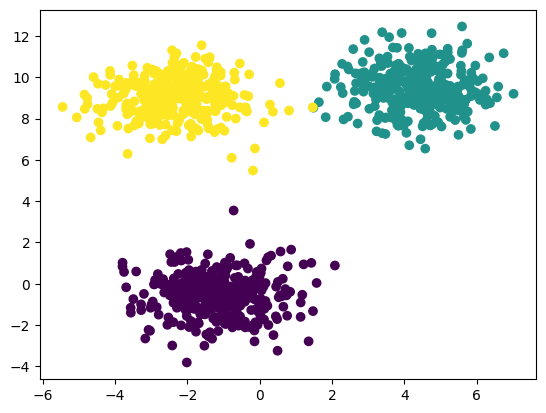

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)

In [6]:
## Standardization-- feature scaling technique 
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [8]:
from sklearn.model_selection import train_test_split 

In [9]:
X_train,X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.33, random_state=42
)

In [10]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [11]:
from sklearn.cluster import KMeans

In [12]:
## Elbow Method to select K Value 
WCSS = []
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    WCSS.append(kmeans.inertia_)

In [13]:
WCSS

[1339.9999999999993,
 565.0747675774478,
 107.76455221656305,
 92.97004445674888,
 74.19364776573396,
 59.36019106712781,
 54.47756924160487,
 49.88852897600837,
 44.87513927929718,
 40.42482329061911]

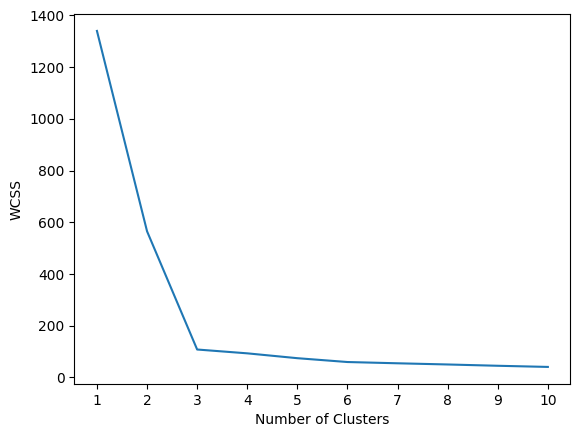

In [14]:
## Plot Elbow Curve 
plt.plot(range(1,11),WCSS)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [15]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [16]:
kmeans.fit_predict(X_train_scaled)

array([2, 0, 2, 1, 2, 1, 1, 2, 1, 0, 2, 2, 2, 0, 2, 0, 0, 2, 2, 0, 0, 1,
       1, 2, 1, 0, 2, 1, 1, 1, 0, 2, 1, 2, 2, 1, 0, 2, 2, 2, 2, 2, 2, 0,
       2, 0, 1, 2, 2, 1, 2, 2, 1, 1, 0, 0, 0, 2, 2, 2, 2, 2, 1, 0, 2, 1,
       0, 0, 2, 2, 0, 1, 1, 1, 2, 2, 0, 0, 1, 1, 1, 1, 2, 2, 2, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 2, 1, 1, 0, 2, 2, 0, 1, 1, 2, 1,
       2, 1, 2, 1, 2, 0, 1, 1, 2, 1, 2, 0, 1, 0, 1, 0, 2, 0, 1, 0, 0, 2,
       0, 2, 1, 0, 0, 0, 2, 1, 1, 2, 1, 1, 0, 1, 2, 2, 1, 1, 0, 1, 2, 0,
       2, 0, 2, 1, 2, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 0, 1, 2, 2, 1, 0,
       1, 2, 1, 2, 0, 0, 2, 2, 2, 1, 1, 1, 2, 1, 0, 1, 0, 0, 2, 1, 2, 0,
       1, 1, 2, 1, 1, 0, 0, 1, 2, 1, 2, 0, 2, 1, 1, 0, 1, 1, 1, 0, 2, 1,
       0, 2, 1, 2, 2, 0, 0, 0, 0, 1, 2, 0, 0, 1, 2, 2, 0, 0, 1, 1, 1, 2,
       2, 0, 0, 2, 0, 0, 1, 2, 0, 0, 1, 0, 0, 0, 2, 0, 1, 1, 0, 0, 2, 2,
       0, 1, 2, 1, 1, 2, 2, 0, 1, 1, 2, 2, 0, 1, 1, 0, 2, 2, 1, 0, 1, 1,
       0, 1, 2, 2, 2, 0, 0, 2, 0, 0, 2, 1, 2, 1, 1,

In [17]:
y_pred = kmeans.predict(X_test_scaled)

In [18]:
y_pred

array([2, 0, 0, 1, 0, 2, 0, 2, 1, 0, 0, 0, 1, 0, 2, 0, 0, 1, 1, 1, 0, 1,
       1, 2, 1, 1, 2, 0, 2, 2, 0, 1, 1, 2, 0, 0, 0, 1, 2, 1, 1, 2, 1, 0,
       2, 1, 2, 1, 0, 1, 2, 1, 1, 0, 0, 0, 2, 2, 1, 1, 0, 1, 2, 1, 0, 2,
       2, 0, 2, 2, 1, 2, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 2, 0, 1, 1, 0, 0,
       0, 1, 0, 2, 0, 2, 1, 0, 2, 1, 0, 1, 2, 2, 1, 2, 0, 2, 0, 1, 1, 2,
       0, 0, 0, 2, 2, 1, 2, 1, 0, 0, 2, 2, 2, 1, 1, 0, 0, 2, 1, 0, 1, 2,
       0, 0, 0, 2, 1, 0, 0, 1, 0, 1, 2, 1, 0, 0, 2, 2, 2, 0, 2, 1, 1, 0,
       2, 1, 1, 1, 1, 0, 2, 2, 0, 0, 1, 1, 2, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 2, 2, 0, 1, 0, 1, 1, 2, 2, 1, 2, 1, 1, 0, 2, 0, 0, 2, 1, 2,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 2, 2, 1, 0, 0, 1, 1, 2, 0, 1, 1, 2, 0,
       2, 0, 0, 2, 2, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 2, 2, 2, 1, 1, 1,
       2, 0, 1, 0, 2, 1, 2, 1, 1, 0, 2, 2, 2, 0, 0, 0, 2, 0, 1, 0, 0, 1,
       2, 2, 0, 0, 2, 0, 2, 1, 0, 2, 2, 2, 0, 1, 2, 2, 0, 0, 2, 0, 0, 2,
       1, 0, 2, 1, 0, 0, 2, 2, 1, 2, 2, 2, 1, 2, 1,

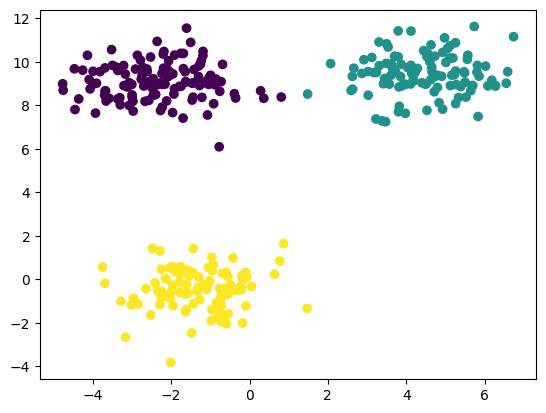

In [23]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [24]:
## Validating the k value 
## KneeLocator 
## Silhoutte Scoring 

In [25]:
## KneeLocator
!pip install kneed

In [26]:
from kneed import KneeLocator 

In [27]:
k1=KneeLocator(range(1,11),WCSS,curve="convex",direction="decreasing")

In [28]:
k1.elbow

np.int64(3)

In [29]:
## Silhoutte Scoring
from sklearn.metrics import silhouette_score

In [32]:
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,kmeans.labels_)
    silhouette_coefficients.append(score)


In [33]:
silhouette_coefficients

[np.float64(0.5784808954109022),
 np.float64(0.758052719301517),
 np.float64(0.6107469931665933),
 np.float64(0.49346046873817967),
 np.float64(0.4591368697122675),
 np.float64(0.3647958711906304),
 np.float64(0.3785158284859918),
 np.float64(0.32903732608098846),
 np.float64(0.31634501689456773)]

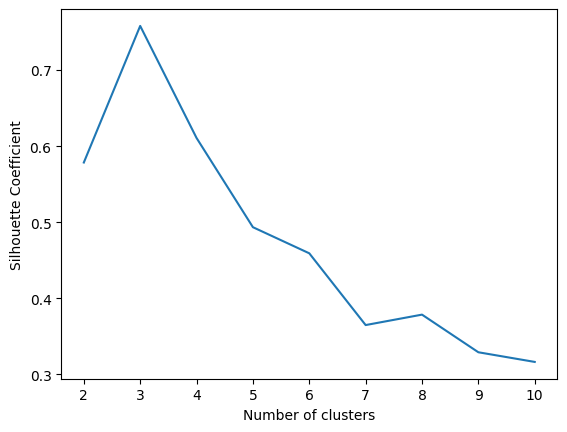

In [34]:
## Plotting Silhoutte Score
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()